# Customer Segmentation — 01: EDA & RFM Feature Construction

**Series:** 01 EDA & RFM (this notebook) → 02 KMeans → 03 DBSCAN →
04 Unsupervised visualization (PCA & t-SNE).

**Dataset:** Online Retail (UCI / Kaggle) — 541,909 transactions of a UK online
retailer, Dec 2010 – Dec 2011. The unsupervised task: segment the customer base from
behavior alone. This notebook audits the transaction log, documents the cleaning
rules, and constructs the **RFM+ feature table** (recency, frequency, monetary,
extended with tenure, product breadth and basket value) that every clustering
notebook consumes identically.

## 1. Setup & data acquisition

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

DATA_PATH = "data/online_retail.csv"
KAGGLE_DATASET = "vijayuv/onlineretail"
MIRROR_URL = (
    "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/"
    "master/data/retail-data/all/online-retail-dataset.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print("Downloaded from mirror.")
    return path


df = pd.read_csv(fetch_data(), encoding="ISO-8859-1")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print(f"Shape: {df.shape}")
print(f"Date range: {df.InvoiceDate.min().date()} → {df.InvoiceDate.max().date()}")
df.head()

100%|██████████| 7.20M/7.20M [00:03<00:00, 2.39MB/s]

Extracting files...


Downloaded from Kaggle: vijayuv/onlineretail
Shape: (541909, 8)
Date range: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Transaction-log audit & cleaning rules

A transaction log is not a customer table — before RFM it needs rules:

In [2]:
canc = df.InvoiceNo.astype(str).str.startswith("C")
print(f"Rows                        : {len(df):,}")
print(f"Missing CustomerID          : {df.CustomerID.isnull().sum():,} "
      f"({df.CustomerID.isnull().mean():.1%})  — guest checkouts, unattributable")
print(f"Cancellation invoices (C…)  : {canc.sum():,}")
print(f"Non-positive quantity       : {(df.Quantity <= 0).sum():,}")
print(f"Non-positive unit price     : {(df.UnitPrice <= 0).sum():,}")

clean = df[~canc & df.CustomerID.notnull() & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
clean["Revenue"] = clean.Quantity * clean.UnitPrice
print(f"\nAfter cleaning: {len(clean):,} rows, {clean.CustomerID.nunique():,} customers, "
      f"total revenue €{clean.Revenue.sum():,.0f}")

Rows                        : 541,909
Missing CustomerID          : 135,080 (24.9%)  — guest checkouts, unattributable
Cancellation invoices (C…)  : 9,288
Non-positive quantity       : 10,624
Non-positive unit price     : 2,517

After cleaning: 397,884 rows, 4,338 customers, total revenue €8,911,408


| Rule | Rationale |
|---|---|
| Drop rows with missing `CustomerID` (~25%) | segmentation is per-customer; guest checkouts cannot be attributed |
| Drop cancellation invoices (`C…`) and their negative quantities | returns are not purchase behavior; netting them properly needs order-level matching beyond this scope |
| Drop non-positive unit prices | free/adjustment lines, not sales |

## 3. RFM+ feature construction

Snapshot date = last transaction + 1 day. Six behavioral features per customer:
the classic **R, F, M** plus **tenure** (days since first purchase), **product
breadth** (unique SKUs) and **average order value** — the extensions give the
dimensionality-reduction notebook something richer than a 3-axis space.

In [3]:
snapshot = clean.InvoiceDate.max() + pd.Timedelta(days=1)

rfm = clean.groupby("CustomerID").agg(
    recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    frequency=("InvoiceNo", "nunique"),
    monetary=("Revenue", "sum"),
    tenure=("InvoiceDate", lambda s: (snapshot - s.min()).days),
    n_products=("StockCode", "nunique"),
)
rfm["avg_order_value"] = rfm.monetary / rfm.frequency
FEATURES = list(rfm.columns)

print(f"Customer table: {rfm.shape[0]:,} customers × {rfm.shape[1]} features")
print(rfm.describe().round(1).to_string())

Customer table: 4,338 customers × 6 features
       recency  frequency  monetary  tenure  n_products  avg_order_value
count   4338.0     4338.0    4338.0  4338.0      4338.0           4338.0
mean      92.5        4.3    2054.3   223.3        61.5            419.2
std      100.0        7.7    8989.2   117.9        85.4           1796.5
min        1.0        1.0       3.8     1.0         1.0              3.4
25%       18.0        1.0     307.4   113.0        16.0            178.6
50%       51.0        2.0     674.5   249.0        35.0            293.9
75%      142.0        5.0    1661.7   327.0        77.0            430.1
max      374.0      209.0  280206.0   374.0      1787.0          84236.2


## 4. Distributions — why log transforms are non-negotiable

Every monetary/count feature is heavily right-skewed (a few whales, a long tail of
one-time buyers). K-distance and centroid geometry both live in Euclidean space, so
clustering raw values would let `monetary`'s tail dominate everything.

                 raw_skew  log1p_skew
recency              1.25       -0.38
frequency           12.07        1.21
monetary            19.32        0.39
tenure              -0.37       -1.56
n_products           6.92       -0.24
avg_order_value     41.69        0.23


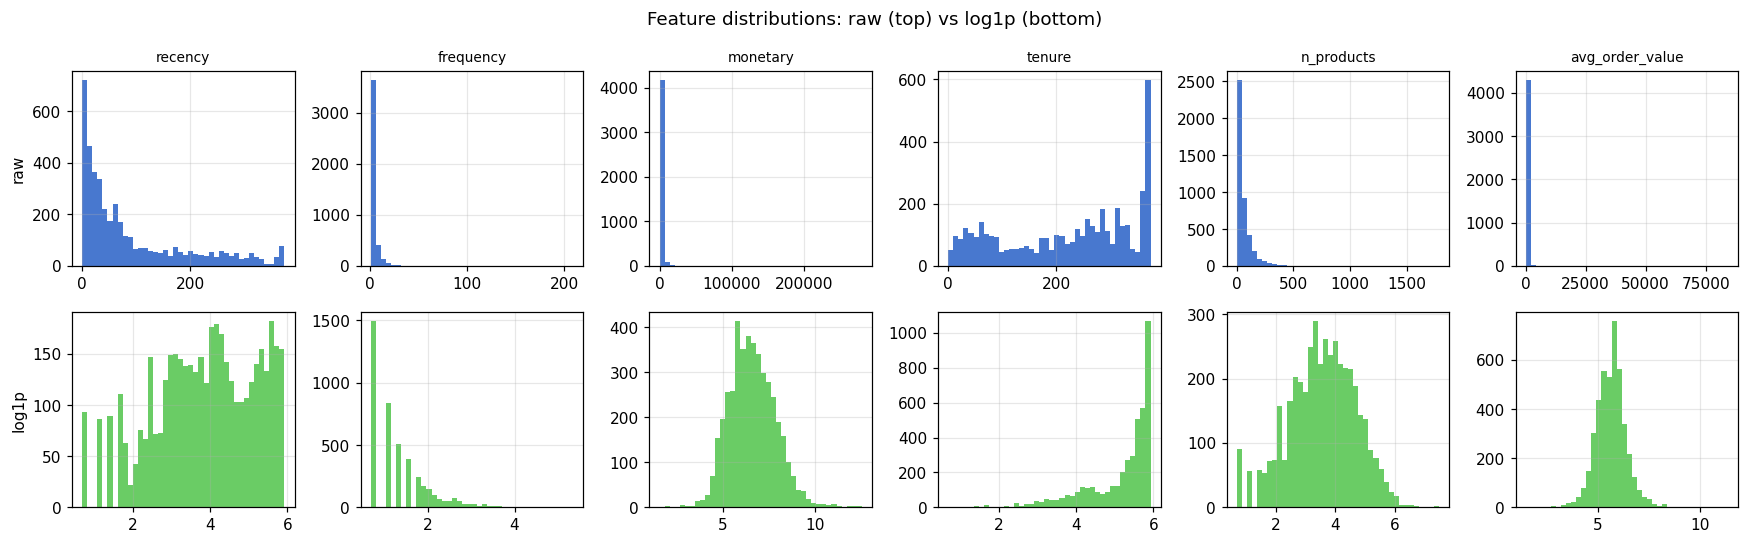

In [4]:
skew = rfm.skew().rename("raw_skew").to_frame()
skew["log1p_skew"] = np.log1p(rfm).skew()
print(skew.round(2).to_string())

fig, axes = plt.subplots(2, 6, figsize=(16, 5))
for j, col in enumerate(FEATURES):
    axes[0, j].hist(rfm[col], bins=40, color="#4878CF")
    axes[0, j].set_title(col, fontsize=9)
    axes[1, j].hist(np.log1p(rfm[col]), bins=40, color="#6ACC65")
axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("log1p")
plt.suptitle("Feature distributions: raw (top) vs log1p (bottom)")
plt.tight_layout()
plt.show()

`log1p` pulls skews from the 5–19 range down to ≈ |1|. The clustering notebooks use a
shared preprocessing: **`log1p` → `StandardScaler`**, fit identically everywhere.

## 5. Structure between features

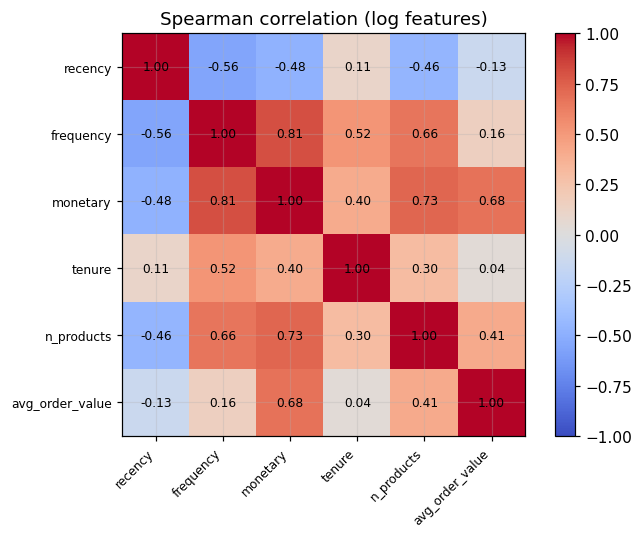

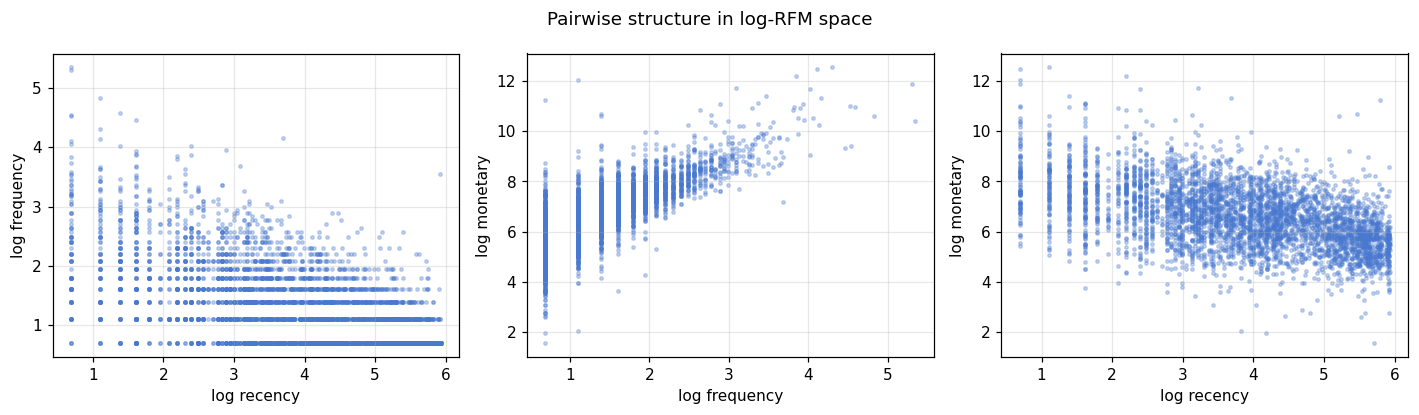

In [5]:
logf = np.log1p(rfm)
corr = logf.corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("Spearman correlation (log features)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
pairs = [("recency", "frequency"), ("frequency", "monetary"), ("recency", "monetary")]
for ax, (a, b) in zip(axes, pairs):
    ax.scatter(logf[a], logf[b], s=5, alpha=0.3, c="#4878CF")
    ax.set_xlabel(f"log {a}")
    ax.set_ylabel(f"log {b}")
plt.suptitle("Pairwise structure in log-RFM space")
plt.tight_layout()
plt.show()

Two things the clustering notebooks should expect:

1. **An engagement block**: `frequency`, `monetary` and `n_products` are strongly
   positively correlated (ρ ≈ 0.7–0.9) — one "how much of a customer are you" axis —
   with `recency` opposing it. PCA (notebook 04) should compress this block into a
   dominant first component.
2. **No visually separated islands**: the scatter panels show one continuous cloud
   with density gradients, not distinct modes. That predicts centroid methods will
   *partition* the cloud usefully while density methods (DBSCAN) will struggle to find
   multiple separated clusters — a hypothesis notebooks 02 and 03 test explicitly.

**Next:** notebook 02 — KMeans with elbow, silhouette curve and per-cluster
silhouette (knife) plots, then segment profiling and actions.